In [1]:
import os

# Set the environment variables
os.environ["PYTORCH_NO_CUDA_MEMORY_CACHING"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:25,garbage_collection_threshold:0.5,expandable_segments:True"

# Verify the settings with improved output
print("Environment Variable Settings:")
print(f"  PYTORCH_NO_CUDA_MEMORY_CACHING: {os.environ.get('PYTORCH_NO_CUDA_MEMORY_CACHING', 'Not Set')}")
print(f"  PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF', 'Not Set')}")

print("-" * 30) # add a seperator.

Environment Variable Settings:
  PYTORCH_NO_CUDA_MEMORY_CACHING: 1
  PYTORCH_CUDA_ALLOC_CONF: max_split_size_mb:25,garbage_collection_threshold:0.5,expandable_segments:True
------------------------------


In [2]:
import pickle
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import numpy as np
import geneformer
from geneformer import TranscriptomeTokenizer
import scanpy as sc
import anndata as an
from datasets import Dataset, load_from_disk
from scipy.spatial.distance import cdist
import torch
import gc
from importlib import reload
import umap

# local functions
sys.path.append("../../utils/")
import geneformer_utils as ut

In [3]:
print(f"Torch Version: {torch.__version__}")
print(f"CUDA Version: {torch.version.cuda}")

Torch Version: 2.6.0+cu124
CUDA Version: 12.4


In [4]:
device = torch.device("cuda")
print(f"CUDA device available: {torch.cuda.get_device_name(0)}")

# Get total RAM
total_memory = torch.cuda.get_device_properties(0).total_memory
print(f"Total GPU memory: {total_memory / (1024**3):.2f} GB")

# Get allocated RAM
allocated_memory = torch.cuda.memory_allocated(0)
print(f"Allocated GPU memory: {allocated_memory / (1024**3):.2f} GB")

# Get cached RAM
cached_memory = torch.cuda.memory_reserved(0)
print(f"Cached GPU memory: {cached_memory / (1024**3):.2f} GB")

CUDA device available: NVIDIA A100 80GB PCIe MIG 3g.40gb
Total GPU memory: 39.25 GB
Allocated GPU memory: 0.00 GB
Cached GPU memory: 0.00 GB


In [5]:
# break

# Model choice

In [6]:
model_str = '95m'
params_file = "../../resources/geneformer_params.yaml"

with open(params_file, 'r') as file:
    params = yaml.safe_load(file)

model = params['models'][model_str]
print(json.dumps(model, indent=2))

{
  "model_path": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/gf-12L-95M-i4096/",
  "gene_median": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/gene_median_dictionary_gc95M.pkl",
  "token_dictionary_file": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/token_dictionary_gc95M.pkl",
  "gene_mapping_file": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/ensembl_mapping_dict_gc95M.pkl",
  "model_input_size": 4096,
  "special_token": true
}


# load the id mapping

In [7]:
with open(model['token_dictionary_file'], 'rb') as f:  
    tokens = pickle.load(f)

print(f"{len(tokens)=}")

len(tokens)=20275


In [8]:
with open(model['gene_mapping_file'], 'rb') as f:  
    gene_map = pickle.load(f)

print(f"{len(gene_map)=}")

len(gene_map)=173697


In [9]:
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']

tf_df = []
for tf in tf_recipe:
    ens_id = gene_map[tf]
    token_id = tokens[ens_id]
    tf_df.append((tf, ens_id, token_id))

tf_df = pd.DataFrame(tf_df, columns=["TF", "ensembl_ID", "token_ID"])
print(tf_df.to_string(index=False))

    TF      ensembl_ID  token_ID
 GATA2 ENSG00000179348     14205
 GFI1B ENSG00000165702     11475
   FOS ENSG00000170345     12558
STAT5A ENSG00000126561      5761
   REL ENSG00000162924     10694


# Load the tokenized data

In [10]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer/pseudotime.dataset"

data = load_from_disk(fpath)
print(f"{data.shape=}")

df = data.to_pandas()
df.head()

data.shape=(15867, 11)
CPU times: user 39.4 ms, sys: 121 ms, total: 161 ms
Wall time: 590 ms


,input_ids,batch,phase,n_counts,mean_pseudotime,mean_order,nnz,S_score,G2M_score,cluster_str,length
0,"[2, 10172, 10171, 2839, 2706, 15305, 14422, 27...",hsc,G1,3679,0.808782,0.0,3679,-0.005952,-1.192717,C3,3436
1,"[2, 17488, 17862, 15445, 13841, 17068, 6943, 6...",hsc,G1,3987,0.922000,7688.0,3987,-0.198413,-1.039894,C3,3679
2,"[2, 10172, 13391, 18079, 14211, 283, 1136, 197...",hsc,S,2585,0.264203,9543.0,2585,0.714286,-0.243658,C4,2418
3,"[2, 12826, 18282, 19836, 8699, 2968, 18815, 72...",hsc,G1,2358,0.295864,15150.0,2358,-0.121032,-0.625818,C5,2228
4,"[2, 145, 20006, 19409, 18880, 18408, 11013, 78...",hsc,G1,4995,0.787087,6684.0,4995,-0.444444,-2.328151,C2,4096


# Perturb

In [11]:
# get control cells in each phase

tf_list = tf_df['token_ID'].to_list()

def adjust_input_ids(ids, tf_list, max_len=4096):
    # Prepend
    new_ids = tf_list + ids
    # Trim if too long
    if len(new_ids) > max_len:
        return new_ids[:max_len]
    # Pad with tf_list if too short
    pad_needed = max_len - len(new_ids)
    return new_ids + tf_list[:pad_needed]


perturbed = []
unperturbed = []

for phase in ['G1', 'S', 'G2M']:
    data = df[(df['phase'] == phase) & (df['batch'] == 'fib')].reset_index(drop=True)
    data['cell_id'] = [f"{phase}_{x+1}" for x in range(len(data))]
    unperturbed.append(data.copy())

    # add the TFs
    data['input_ids'] = data['input_ids'].apply(lambda x: adjust_input_ids(list(x), tf_list)).copy()
    perturbed.append(data)


unperturbed = pd.concat(unperturbed, ignore_index=True)  
print(f"{unperturbed.shape=}")
print(unperturbed[['input_ids', 'cluster_str', 'batch', 'cell_id']].head())
print()

perturbed = pd.concat(perturbed, ignore_index=True)  
print(f"{perturbed.shape=}")
print(perturbed[['input_ids', 'cluster_str', 'batch', 'cell_id']].head())

unperturbed.shape=(7541, 12)
                                           input_ids cluster_str batch cell_id
0  [2, 20165, 283, 15343, 859, 11250, 7071, 4387,...          C5   fib    G1_1
1  [2, 283, 7071, 11714, 4230, 9106, 872, 17125, ...          C5   fib    G1_2
2  [2, 20165, 19409, 283, 11250, 2838, 7787, 9186...          C5   fib    G1_3
3  [2, 20165, 17267, 11250, 283, 7787, 18699, 117...          C5   fib    G1_4
4  [2, 20184, 14422, 7071, 283, 7787, 7094, 8794,...          C5   fib    G1_5

perturbed.shape=(7541, 12)
                                           input_ids cluster_str batch cell_id
0  [14205, 11475, 12558, 5761, 10694, 2, 20165, 2...          C5   fib    G1_1
1  [14205, 11475, 12558, 5761, 10694, 2, 283, 707...          C5   fib    G1_2
2  [14205, 11475, 12558, 5761, 10694, 2, 20165, 1...          C5   fib    G1_3
3  [14205, 11475, 12558, 5761, 10694, 2, 20165, 1...          C5   fib    G1_4
4  [14205, 11475, 12558, 5761, 10694, 2, 20184, 1...          C5   fib    

<!-- break -->

# Model Definition

In [12]:
gene_median = model['gene_median']
token_dictionary_file = model['token_dictionary_file']
gene_mapping_file = model['gene_mapping_file']

In [13]:
# load and reverse the token mapping
token_dict = ut.load_pickle(token_dictionary_file)
token_dict = {v: k for k, v in token_dict.items()} # WHY?
print(f"{len(token_dict)=}")

model_obj = ut.load_model(model['model_path'])
# print(model_obj)
print('ready!')

len(token_dict)=20275
ready!


# Cell Emebdddings

In [14]:
torch.cuda.empty_cache()

n_cells = 7541
cell_idx = unperturbed['cell_id'].sample(n_cells).values 

edatas = []
for dataset in [unperturbed, perturbed]:
    edata = ut.extract_cell_embeddings(
        model=model_obj,
        data=Dataset.from_pandas(dataset[dataset['cell_id'].isin(cell_idx)]),
        token_gene_dict=token_dict,
    )

    edatas.append(edata)

edata = an.concat(edatas, axis=0, join='outer', label='condition', keys=['unperturbed', 'perturbed'])
edata.obs.head()

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


  0%|          | 0/755 [00:00<?, ?it/s]

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


  0%|          | 0/755 [00:00<?, ?it/s]

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


,input_ids,batch,phase,n_counts,mean_pseudotime,mean_order,nnz,S_score,G2M_score,cluster_str,length,cell_id,condition
0,[ 2 20165 283 ... 13986 18014 3],fib,G1,2798,0.2783416211605072,14582.5,2798,-0.11507936507936509,-1.4864975450081832,C5,2652,G1_1,unperturbed
1,[ 2 283 7071 ... 18014 5175 3],fib,G1,3053,0.2518965005874634,3776.5,3053,-0.0873015873015873,-1.8213993453355155,C5,2835,G1_2,unperturbed
2,[ 2 20165 19409 ... 8873 18014 3],fib,G1,3221,0.2831133306026459,14758.5,3221,-0.22023809523809526,-1.4754500818330607,C5,3035,G1_3,unperturbed
3,[ 2 20165 17267 ... 15304 10916 3],fib,G1,3030,0.24481573700904846,10398.0,3030,-0.1349206349206349,-1.5652618657937807,C5,2855,G1_4,unperturbed
4,[ 2 20184 14422 ... 5175 16934 3],fib,G1,4021,0.25627413392066956,3600.0,4021,-0.3214285714285714,-1.983224222585925,C5,3773,G1_5,unperturbed


/tmp/ipykernel_3874745/632519107.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


unique cells: 7541
X.shape=(7541, 512)
Y.shape=(7541, 512)
distances.shape=(7541,)


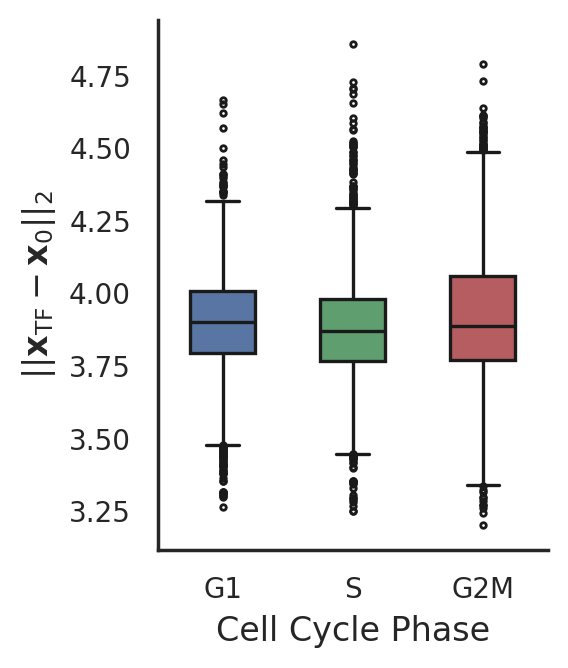

In [15]:
pdf = edata.obs.drop_duplicates(subset=['cell_id'])
pdf = pdf.drop(columns=['input_ids'])
print(f"unique cells: {pdf.shape[0]}")

X = edata[edata.obs['condition'] == 'unperturbed', :].X
Y = edata[edata.obs['condition'] == 'perturbed', :].X

print(f"{X.shape=}")
print(f"{Y.shape=}")

# Convert to dense if needed
X_dense = X.toarray() if not isinstance(X, np.ndarray) else X
Y_dense = Y.toarray() if not isinstance(Y, np.ndarray) else Y

# Ensure same number of rows
assert X_dense.shape[0] == Y_dense.shape[0], "X and Y must have the same number of rows"

# Row-wise Euclidean distances
distances = np.linalg.norm(X_dense - Y_dense, axis=1)
print(f"{distances.shape=}")

# add distances
pdf['distance'] = np.ravel(distances)
sns.set_theme(style="white")
plt.figure(figsize=(3, 3.5), dpi=200)

palette = {
    'G1':  '#4C72B0',  # blue
    'S':   '#55A868',  # green
    'G2M': '#C44E52'   # red
}

ax = sns.boxplot(
    data=pdf,
    x='phase',
    y='distance',
    width=0.5,
    linecolor='k',
    legend=False,
    flierprops={'markersize' : 2},
    linewidth=1.2,
    palette=palette,
)

ax.set_xlabel("Cell Cycle Phase", fontsize=12)
ax.set_ylabel(r"$||\mathbf{x}_{\mathrm{TF}} - \mathbf{x}_{0}||_2$", fontsize=12)

ax.tick_params(labelsize=10)
sns.despine()
plt.tight_layout()
plt.show()

unique cells: 7541


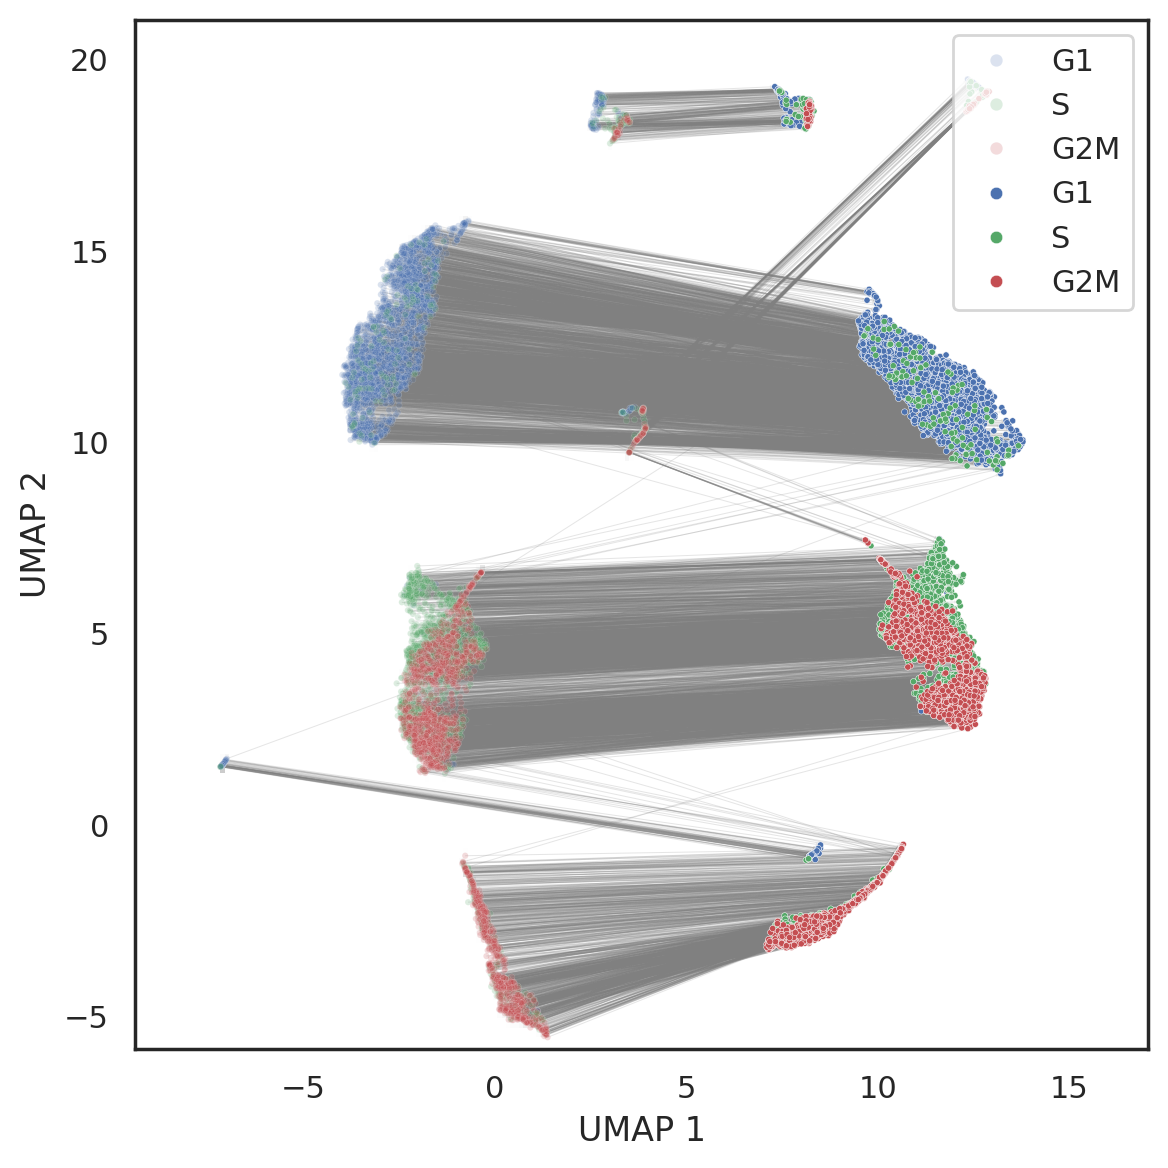

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

pdf = edata.obs.drop_duplicates(subset=['cell_id'])
pdf = pdf.drop(columns=['input_ids'])
print(f"unique cells: {pdf.shape[0]}")

# Convert to dense
X_dense = X.toarray() if not isinstance(X, np.ndarray) else X
Y_dense = Y.toarray() if not isinstance(Y, np.ndarray) else Y

# Reduce to 2D
reducer = umap.UMAP()
XY_2d = reducer.fit_transform(np.vstack([X_dense, Y_dense]))
n = X_dense.shape[0]
X_2d = XY_2d[:n]
Y_2d = XY_2d[n:]

# Displacement vectors
U = Y_2d[:, 0] - X_2d[:, 0]
V = Y_2d[:, 1] - X_2d[:, 1]

# Grid definition
nbins = 100
all_x = np.concatenate([X_2d[:, 0], Y_2d[:, 0]])
all_y = np.concatenate([X_2d[:, 1], Y_2d[:, 1]])
x_edges = np.linspace(all_x.min(), all_x.max(), nbins)
y_edges = np.linspace(all_y.min(), all_y.max(), nbins)

Xc = 0.5 * (x_edges[:-1] + x_edges[1:])
Yc = 0.5 * (y_edges[:-1] + y_edges[1:])
X_mesh, Y_mesh = np.meshgrid(Xc, Yc)

# Bin and average vectors into grid
dx = np.zeros_like(X_mesh)
dy = np.zeros_like(Y_mesh)
counts = np.zeros_like(X_mesh)

for x, y, u, v in zip(X_2d[:, 0], X_2d[:, 1], U, V):
    ix = np.searchsorted(x_edges, x) - 1
    iy = np.searchsorted(y_edges, y) - 1
    if 0 <= ix < nbins - 1 and 0 <= iy < nbins - 1:
        dx[iy, ix] += u
        dy[iy, ix] += v
        counts[iy, ix] += 1

counts[counts == 0] = 1
dx /= counts
dy /= counts

# Smooth
dx_smooth = gaussian_filter(dx, sigma=1)
dy_smooth = gaussian_filter(dy, sigma=1)

# Optional: background density
xy_all = np.vstack([X_2d[:, 0], X_2d[:, 1]]).T
plt.figure(figsize=(6, 6), dpi=200)
plt.hist2d(xy_all[:, 0], xy_all[:, 1], bins=100, cmap='Greys', alpha=0.3)

scale_factor = 1.0
plt.quiver(
    X_2d[:, 0], X_2d[:, 1], 
    U * scale_factor, V * scale_factor,
    angles='xy', scale_units='xy', scale=1,
    width=0.001, alpha=0.2, color='gray'
)

# Plot start points (X_2d) in blue
sns.scatterplot(
    data=pdf,
    x=X_2d[:, 0], 
    y=X_2d[:, 1],
    s=5, 
    hue='phase',
    alpha=0.2,
    palette=palette,
)

# Plot end points (Y_2d) in red
sns.scatterplot(
    data=pdf,
    x=Y_2d[:, 0], 
    y=Y_2d[:, 1], 
    s=5, 
    hue='phase',
    palette=palette,
)


plt.legend(loc='upper right', markerscale=2)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.axis("equal")
plt.tight_layout()
plt.show()


unique cells: 7541


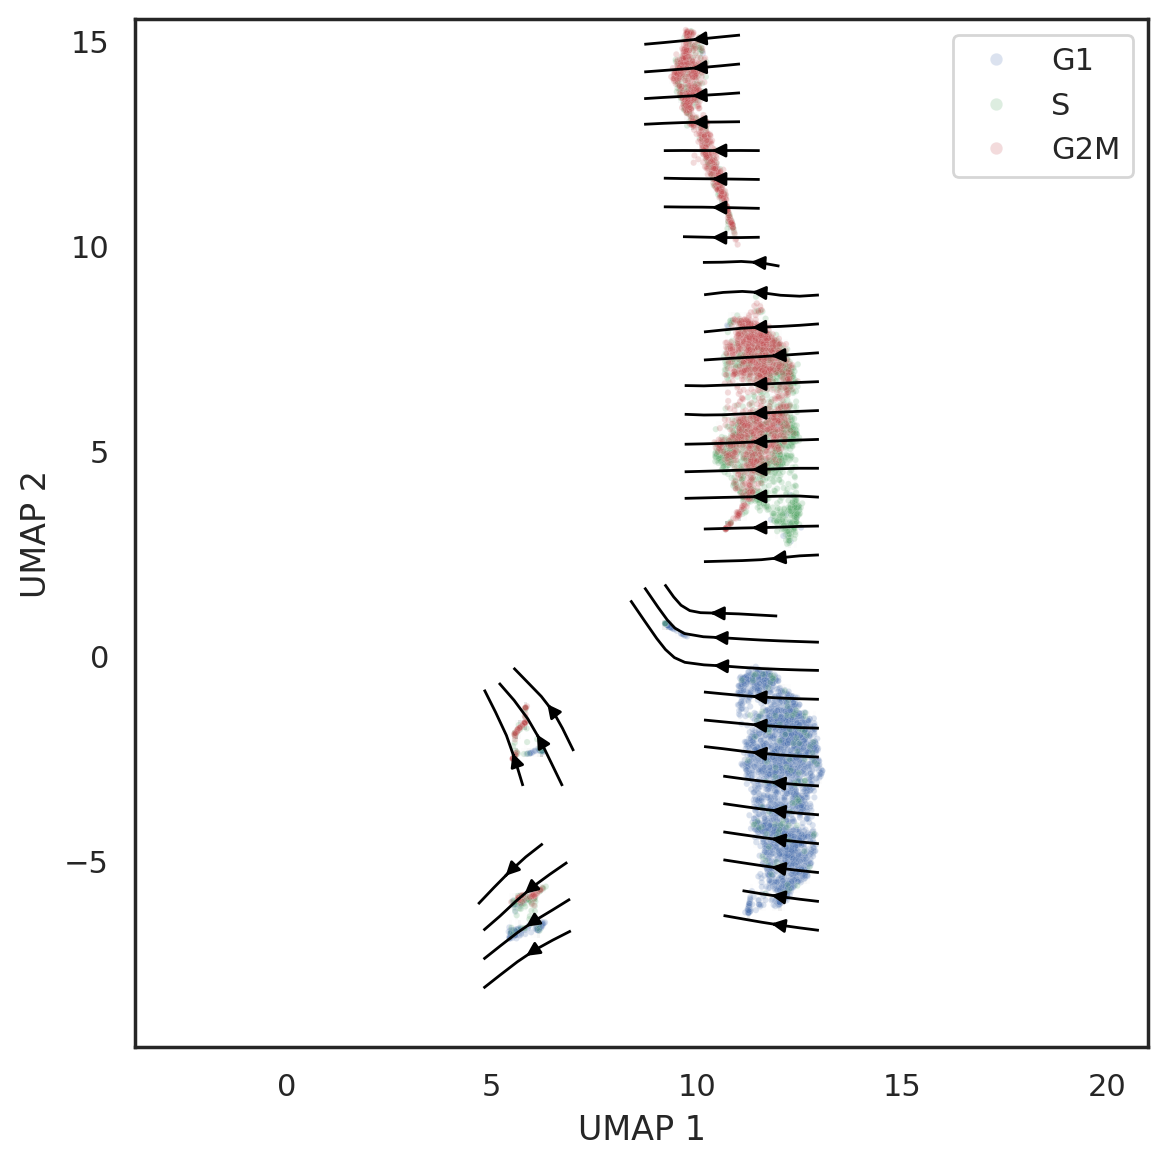

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

pdf = edata.obs.drop_duplicates(subset=['cell_id'])
pdf = pdf.drop(columns=['input_ids'])
print(f"unique cells: {pdf.shape[0]}")

# Convert to dense
X_dense = X.toarray() if not isinstance(X, np.ndarray) else X
Y_dense = Y.toarray() if not isinstance(Y, np.ndarray) else Y

# Reduce to 2D
reducer = umap.UMAP()
XY_2d = reducer.fit_transform(np.vstack([X_dense, Y_dense]))
n = X_dense.shape[0]
X_2d = XY_2d[:n]
Y_2d = XY_2d[n:]

# Displacement vectors
U = Y_2d[:, 0] - X_2d[:, 0]
V = Y_2d[:, 1] - X_2d[:, 1]

# Grid definition
nbins = 100
all_x = np.concatenate([X_2d[:, 0], Y_2d[:, 0]])
all_y = np.concatenate([X_2d[:, 1], Y_2d[:, 1]])
x_edges = np.linspace(all_x.min(), all_x.max(), nbins)
y_edges = np.linspace(all_y.min(), all_y.max(), nbins)

Xc = 0.5 * (x_edges[:-1] + x_edges[1:])
Yc = 0.5 * (y_edges[:-1] + y_edges[1:])
X_mesh, Y_mesh = np.meshgrid(Xc, Yc)

# Bin and average vectors into grid
dx = np.zeros_like(X_mesh)
dy = np.zeros_like(Y_mesh)
counts = np.zeros_like(X_mesh)

for x, y, u, v in zip(X_2d[:, 0], X_2d[:, 1], U, V):
    ix = np.searchsorted(x_edges, x) - 1
    iy = np.searchsorted(y_edges, y) - 1
    if 0 <= ix < nbins - 1 and 0 <= iy < nbins - 1:
        dx[iy, ix] += u
        dy[iy, ix] += v
        counts[iy, ix] += 1

counts[counts == 0] = 1
dx /= counts
dy /= counts

# Smooth
dx_smooth = gaussian_filter(dx, sigma=1)
dy_smooth = gaussian_filter(dy, sigma=1)

# Optional: background density
xy_all = np.vstack([X_2d[:, 0], X_2d[:, 1]]).T
plt.figure(figsize=(6, 6), dpi=200)
plt.hist2d(xy_all[:, 0], xy_all[:, 1], bins=100, cmap='Greys', alpha=0.3)

scale_factor = 2.0  # try 2–5
plt.streamplot(
    Xc, Yc,
    dx_smooth * scale_factor,
    dy_smooth * scale_factor,
    color='black',
    density=1.2,
    linewidth=1,
    arrowsize=1
)

# Plot start points (X_2d) in blue
sns.scatterplot(
    data=pdf,
    x=X_2d[:, 0], 
    y=X_2d[:, 1],
    s=5, 
    hue='phase',
    alpha=0.2,
    palette=palette,
)

# # Plot end points (Y_2d) in red
# sns.scatterplot(
#     data=pdf,
#     x=Y_2d[:, 0], 
#     y=Y_2d[:, 1], 
#     s=5, 
#     hue='phase',
#     palette=palette,
# )

plt.legend(loc='upper right', markerscale=2)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.axis("equal")
plt.tight_layout()
plt.show()


In [18]:
# import numpy as np
# import matplotlib.pyplot as plt
# import umap
# from scipy.ndimage import gaussian_filter

# # Convert to dense
# X_dense = X.toarray() if not isinstance(X, np.ndarray) else X
# Y_dense = Y.toarray() if not isinstance(Y, np.ndarray) else Y

# # Reduce to 2D
# reducer = umap.UMAP()
# XY_combined = np.vstack([X_dense, Y_dense])
# XY_2d = reducer.fit_transform(XY_combined)

# n = X_dense.shape[0]
# X_2d = XY_2d[:n]
# Y_2d = XY_2d[n:]

# # Displacement vectors
# U = Y_2d[:, 0] - X_2d[:, 0]
# V = Y_2d[:, 1] - X_2d[:, 1]

# # Combine into array for grid binning
# X_grid = X_2d[:, 0]
# Y_grid = X_2d[:, 1]

# # Define grid
# nbins = 30
# x_edges = np.linspace(X_grid.min(), X_grid.max(), nbins)
# y_edges = np.linspace(Y_grid.min(), Y_grid.max(), nbins)
# dx = np.zeros((nbins - 1, nbins - 1))
# dy = np.zeros((nbins - 1, nbins - 1))
# counts = np.zeros((nbins - 1, nbins - 1))

# # Bin vectors into the grid
# for x, y, u, v in zip(X_grid, Y_grid, U, V):
#     ix = np.searchsorted(x_edges, x) - 1
#     iy = np.searchsorted(y_edges, y) - 1
#     if 0 <= ix < nbins - 1 and 0 <= iy < nbins - 1:
#         dx[iy, ix] += u
#         dy[iy, ix] += v
#         counts[iy, ix] += 1

# # Avoid division by zero
# counts[counts == 0] = 1
# dx /= counts
# dy /= counts

# # Apply Gaussian smoothing
# dx_smooth = gaussian_filter(dx, sigma=1)
# dy_smooth = gaussian_filter(dy, sigma=1)

# # Compute grid centers
# Xc = 0.5 * (x_edges[:-1] + x_edges[1:])
# Yc = 0.5 * (y_edges[:-1] + y_edges[1:])
# X_mesh, Y_mesh = np.meshgrid(Xc, Yc)

# # Plot
# plt.figure(figsize=(6, 6), dpi=200)
# plt.quiver(
#     X_mesh, Y_mesh, dx_smooth, dy_smooth,
#     angles='xy', scale_units='xy', scale=1,
#     width=0.004, alpha=0.9
# )
# plt.xlabel("UMAP 1")
# plt.ylabel("UMAP 2")
# plt.axis("equal")
# plt.tight_layout()
# plt.show()

In [19]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)